First 5 rows of dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_wors

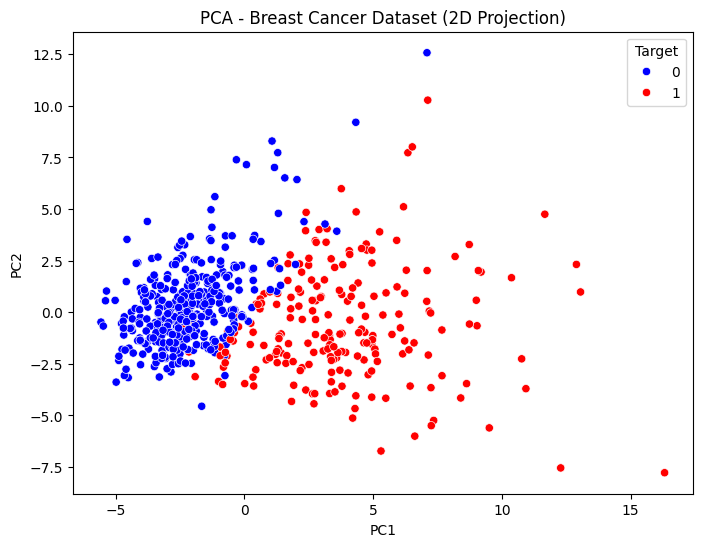

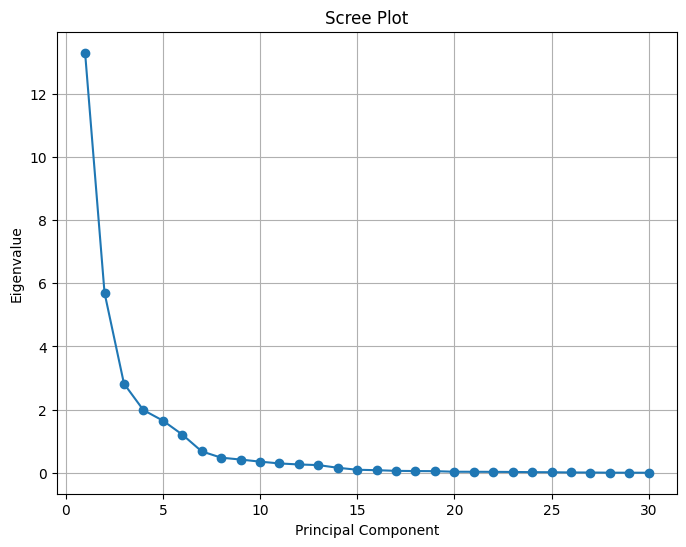

In [5]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 2: Load Dataset
data = pd.read_csv("data.csv")  

print("First 5 rows of dataset:")
print(data.head())

# Step 3: Preprocessing
data = data.drop(['id', 'Unnamed: 32'], axis=1)

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

y = y.map({'M':1, 'B':0})

# Step 4: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: PCA for 2 Components (for visualization)
pca = PCA(n_components=2)  
X_pca = pca.fit_transform(X_scaled)

print("\nExplained Variance Ratio (2 Components):")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:",
      sum(pca.explained_variance_ratio_))

# Step 6: PCA DataFrame for Scatter Plot
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y

# Step 7: Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Target',
    data=pca_df,
    palette=['blue', 'red']
)
plt.title("PCA - Breast Cancer Dataset (2D Projection)")
plt.show()

# -----------------------------
# Step 8: Scree Plot
# -----------------------------

# Apply PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,6))
plt.plot(
    range(1, len(pca_full.explained_variance_)+1),
    pca_full.explained_variance_,
    marker='o'
)
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.grid(True)
plt.show()